# Дополнительные материалы

В дополнительных материалах мы:
* рассмотрим понятие валидационной выборки, а также еще один несложный инструмент регуляризации;
* с нуля разработаем нейросеть с оптимизатором Adam (и таким образом создадим такую же сеть, как на последнем занятии вводного курса, но без использования Keras);
* подробнее изучим различные особенности реализации нейросети в библиотеке Keras.

***Примечание.*** Сегодня мы в большей степени будем сосредоточены на техническом
аспекте создания и обучения моделей, а не на поиске оптимальных
гиперпараметров и параметров.
## Полезное введение
### Обучающая, валидационная и тестовая выборки
В процессе решения задачи машинного обучения помимо непосредственного обучения модели необходимо выбрать алгоритм, подобрать архитектуру (в случае нейросети), настроить гиперпараметры, отобрать или создать новые признаки и т.д.

Если мы будем производить оценку упомянутых вариантов с помощью тестовых данных, то модель выучит их и, таким образом, ухудшит свою обобщающую способность.
![](https://drive.google.com/uc?export=view&id=19tcy2rIKx_zLyYchCilWyNFHCqrff2kR)

Решение заключается в том, чтобы разделить данные на три части: обучающую (train), валидационную (validation) и тестовую (test) выборки.

![](https://drive.google.com/uc?export=view&id=1mmi7S_2MM0Jm0HOJz-4Epq-AUg6EXriY)

Вначале на обучающем и валидационном множествах выбирается алгоритм,
выполяется поиск гиперпараметров и работа с признаками. Затем на тестовых
данных оценивается качество финальной модели.

![](https://drive.google.com/uc?export=view&id=1bOQumxQrbqxbu0a88BgtO0m0yfyZrXXX)

Тестовые данные в этом случае, поскольку модель их не видит в процессе обучения
и настройки, еще называют hold-out или out-of-sample данными.

Технически такое разделение можно выполнить, например, дважды применив
функцию **train_test_split()**.

Подготовим данные.




In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from tensorflow import keras

## Валидационная выборка

In [2]:
X, y = np.arange(2000).reshape((1000, 2)), np.arange(1000)
X.shape, y.shape

((1000, 2), (1000,))

Зададим пропорции обучающей $r_{train},$ валидационной $r_{val}$ и тестовой
$r_{test}$ выборки.

In [3]:
r_train, r_val, r_test = 0.80, 0.10, 0.10

Разделим изначальные данные сначала на обучающее и тестовое множество, а
затем из первой части выделим валидационную выборку.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = r_test)

r_val_star = r_val / (r_train + r_val)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                  test_size = r_val_star)

y_train.shape, y_val.shape, y_test.shape

((800,), (100,), (100,))

Для сохранения исходных пропорций долю валидационных данных при втором
применении функции $r_{val}^*$ можно рассчитать по формуле

$$ r_{val}^* = \frac{ r_{val} }{ r_{train} + r_{val} } $$

В примере выше

In [5]:
r_val / (r_train + r_val)

0.11111111111111112

### Ранняя остановка обучения
Одним из способом борьбы с переобучением является ранняя остановка (early stopping) обучения. Идея заключается в том, чтобы в процессе подбора параметров «отслеживать» уровень ошибки или какую-либо метрику качества (например,
accuracy) не только на обучающей, но и на валидационной выборках.

Если в процессе обучения при снижающейся на «трейне» ошибке или растущей accuracy эти показатели на валидационных данных наоборот начнут соответственно расти или падать, то обучение стоит остановить, поскольку это означает, что
модель начинает переобучаться.
![](https://drive.google.com/uc?export=view&id=1pJ0ldsJp0zL_MU_l-Mcaqz8jOeu8eoxU)

Примечание. Можно также сказать, что до ранней остановки обучения снижается смещение, а после нее начинает увеличиваться разброс.

![](https://drive.google.com/uc?export=view&id=1C9X_JlKeetsCqLwcG869VH1JvqgApwxq)

Остановку обучения обычно производят не сразу, а в случае если на валидационных данных ошибка растет, а accuracy соответственно падает в течение некоторого количества эпох подряд (чтобы не останавливать обучение из-за
стохастических колебаний градиента/ошибки).

Такое «время ожидания» обычно обозначается через параметр patience.

Создадим нейросеть с оптимизатором Adam, а также реализуем в коде приведенные выше идеи валидационной выборки и ранней остановки обучения.

## Нейросеть с оптимизатором Adam

### Подготовка данных
Скачаем датасет MNIST.

In [6]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Дополнительно выделим валидационную выборку из обучающего множества.

In [7]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                  test_size = 0.2,
                                                  random_state = 42)

Приведем данные к диапазону $[-1,1].$

In [8]:
X_train = 2. * (X_train - np.min(X_train)) / np.ptp(X_train) - 1
X_val = 2. * (X_val - np.min(X_val)) / np.ptp(X_val) - 1
X_test = 2. * (X_test - np.min(X_test)) / np.ptp(X_test) - 1

Превратим изображения в векторы.

In [9]:
X_train = X_train.reshape((-1, 784)).T
X_val = X_val.reshape((-1, 784)).T
X_test = X_test.reshape((-1, 784)).T

Преобразуем целевую переменную с помощью one-hot encoding.

In [10]:
def ohe(y):
  examples, features = y.shape[0], len(np.unique(y))
  zeros_matrix = np.zeros((examples, features))
  for i, (row, digit) in enumerate(zip(zeros_matrix, y)):
    zeros_matrix[i][digit] = 1

  return zeros_matrix

In [11]:
y_train_enc, y_val_enc, y_test_enc = ohe(y_train).T, ohe(y_val).T, ohe(y_test).T

Посмотрим на результат.

In [12]:
X_train.shape, X_val.shape, X_test.shape

((784, 48000), (784, 12000), (784, 10000))

### Функции активации
Объявим функции активации.

In [13]:
def sigmoid(z):
  s = 1 / (1 + np.exp(-z))
  return s

def softmax(z):
  z = z - np.max(z, axis = 0, keepdims = True)
  numerator = np.exp(z)
  denominator = np.sum(numerator, axis = 0, keepdims = True)
  softmax = numerator / denominator
  return softmax

### Функция потерь
И функцию потерь.

In [14]:
def cross_entropy(probs, y_enc, epsilon = 1e-9):
  n = probs.shape[1]
  ce = -np.sum(y_enc * np.log(probs + epsilon)) / n
  return ce

### Схема нейросети
Нейросеть с оптимизатором Adam отслеживает не только обновление параметров, но и первого и второго начальных моментов.
![](https://drive.google.com/uc?export=view&id=1JQPOTZ0rhdJFKDXfxVYT3ts9DrCM-oCA)


### Инициализация параметров и моментов
Параметры инициализируются случайными значениями из стандартного
нормального распределения.

In [15]:
def initialize_params(x, y, random_state = 33):

  np.random.seed(random_state)

  parameters = {}

  parameters['W1'] = np.random.randn(64, x.shape[0])
  parameters['b1'] = np.zeros((64, 1))

  parameters['W2'] = np.random.randn(64, 64)
  parameters['b2'] = np.zeros((64, 1))

  parameters['W3'] = np.random.randn(y.shape[0], 64)
  parameters['b3'] = np.zeros((y.shape[0], 1))

  return parameters

Моменты (той же размерности) инициализируются нулевыми значениями.

In [16]:
# первый начальный момент
def initialize_mk(x, y, random_state = 33):

  np.random.seed(random_state)

  mk = {}

  mk['mW1'] = np.zeros((64, x.shape[0]))
  mk['mb1'] = np.zeros((64, 1))

  mk['mW2'] = np.zeros((64, 64))
  mk['mb2'] = np.zeros((64, 1))

  mk['mW3'] = np.zeros((y.shape[0], 64))
  mk['mb3'] = np.zeros((y.shape[0], 1))

  return mk

In [17]:
# второй начальный момент
def initialize_vk(x, y, random_state = 33):

  np.random.seed(random_state)

  vk = {}

  vk['vW1'] = np.zeros((64, x.shape[0]))
  vk['vb1'] = np.zeros((64, 1))

  vk['vW2'] = np.zeros((64, 64))
  vk['vb2'] = np.zeros((64, 1))

  vk['vW3'] = np.zeros((y.shape[0], 64))
  vk['vb3'] = np.zeros((y.shape[0], 1))

  return vk

### Прямое и обратное распространение
Объявим функцию прямого распространения:
* на вход эта функция будет принимать словарь параметров;
* на выход будет выдавать уроверь ошибки на обучающей выборке и кортеж параметров и значений активационных слоев (cache).

In [18]:
def forward(x, y, parameters):

  n = x.shape[1]

  W1 = parameters['W1']
  b1 = parameters['b1']
  W2 = parameters['W2']
  b2 = parameters['b2']
  W3 = parameters['W3']
  b3 = parameters['b3']

  Z1 = np.dot(W1, x) + b1
  A1 = sigmoid(Z1)

  Z2 = np.dot(W2, A1) + b2
  A2 = sigmoid(Z2)

  Z3 = np.dot(W3, A2) + b3
  A3 = softmax(Z3)

  loss = cross_entropy(A3, y)

  cache = (A1, W1, b1, A2, W2, b2, A3, W3, b3)

  return loss, cache

Функция обратного распространения будет:
* принимать cache и рассчитывать производные;
* принимать словари первого и второго моментов;
* обновлять текущие параметры; и наконец
* выдавать словари обновленных параметров и моментов.

In [19]:
def backward(x, y, cache, mk, vk, i, lr, beta1, beta2):

  n = x.shape[1]
  (A1, W1, b1, A2, W2, b2, A3, W3, b3) = cache
  eps = 1e-8

  W3_delta = A3 - y
  W2_delta = np.dot(W3.T, W3_delta) * A2 * (1 - A2)
  W1_delta = np.dot(W2.T, W2_delta) * A1 * (1 - A1)

  W3_derivative = np.dot(W3_delta, A2.T) / n
  b3_derivative = np.sum(W3_delta, axis = 1, keepdims = True) / n

  W2_derivative = np.dot(W2_delta, A1.T) / n
  b2_derivative = np.sum(W2_delta, axis = 1, keepdims = True) / n

  W1_derivative = np.dot(W1_delta, x.T) / n
  b1_derivative = np.sum(W1_delta, axis = 1, keepdims = True) / n

  mW1 = mk['mW1']
  mb1 = mk['mb1']
  mW2 = mk['mW2']
  mb2 = mk['mb2']
  mW3 = mk['mW3']
  mb3 = mk['mb3']

  vW1 = vk['vW1']
  vb1 = vk['vb1']
  vW2 = vk['vW2']
  vb2 = vk['vb2']
  vW3 = vk['vW3']
  vb3 = vk['vb3']

  mW3 = beta1 * mW3 + (1 - beta1) * W3_derivative
  mb3 = beta1 * mb3 + (1 - beta1) * b3_derivative
  mW2 = beta1 * mW2 + (1 - beta1) * W2_derivative
  mb2 = beta1 * mb2 + (1 - beta1) * b2_derivative
  mW1 = beta1 * mW1 + (1 - beta1) * W1_derivative
  mb1 = beta1 * mb1 + (1 - beta1) * b1_derivative

  vW3 = beta2 * vW3 + (1 - beta2) * np.square(W3_derivative)
  vb3 = beta2 * vb3 + (1 - beta2) * np.square(b3_derivative)
  vW2 = beta2 * vW2 + (1 - beta2) * np.square(W2_derivative)
  vb2 = beta2 * vb2 + (1 - beta2) * np.square(b2_derivative)
  vW1 = beta2 * vW1 + (1 - beta2) * np.square(W1_derivative)
  vb1 = beta2 * vb1 + (1 - beta2) * np.square(b1_derivative)

  mW3_hat = mW3 / (1 - beta1 ** i)
  mb3_hat = mb3 / (1 - beta1 ** i)
  mW2_hat = mW2 / (1 - beta1 ** i)
  mb2_hat = mb2 / (1 - beta1 ** i)
  mW1_hat = mW1 / (1 - beta1 ** i)
  mb1_hat = mb1 / (1 - beta1 ** i)

  vW3_hat = vW3 / (1 - beta2 ** i)
  vb3_hat = vb3 / (1 - beta2 ** i)
  vW2_hat = vW2 / (1 - beta2 ** i)
  vb2_hat = vb2 / (1 - beta2 ** i)
  vW1_hat = vW1 / (1 - beta2 ** i)
  vb1_hat = vb1 / (1 - beta2 ** i)

  mk_upd = {}

  mk_upd['mW3'] = mW3
  mk_upd['mb3'] = mb3
  mk_upd['mW2'] = mW2
  mk_upd['mb2'] = mb2
  mk_upd['mW1'] = mW1
  mk_upd['mb1'] = mb1

  vk_upd = {}

  vk_upd['vW3'] = vW3
  vk_upd['vb3'] = vb3
  vk_upd['vW2'] = vW2
  vk_upd['vb2'] = vb2
  vk_upd['vW1'] = vW1
  vk_upd['vb1'] = vb1

  parameters = {}

  parameters['W3'] = W3 - lr * mW3_hat / (np.sqrt(vW3_hat + eps))
  parameters['b3'] = b3 - lr * mb3_hat / (np.sqrt(vb3_hat + eps))
  parameters['W2'] = W2 - lr * mW2_hat / (np.sqrt(vW2_hat + eps))
  parameters['b2'] = b2 - lr * mb2_hat / (np.sqrt(vb2_hat + eps))
  parameters['W1'] = W1 - lr * mW1_hat / (np.sqrt(vW1_hat + eps))
  parameters['b1'] = b1 - lr * mb1_hat / (np.sqrt(vb1_hat + eps))

  return parameters, mk_upd, vk_upd

### Ошибка на валидационных данных
Для того чтобы реализовать возможность ранней остановки обучения потребуется отдельная функция, которая будет выдавать уровень ошибки на валидационных данных.

In [20]:
def valuation_loss(x_val, y_val, parameters):

  W1 = parameters['W1']
  b1 = parameters['b1']
  W2 = parameters['W2']
  b2 = parameters['b2']
  W3 = parameters['W3']
  b3 = parameters['b3']

  Z1 = np.dot(W1, x_val) + b1
  A1 = sigmoid(Z1)
  Z2 = np.dot(W2, A1) + b2
  A2 = sigmoid(Z2)
  Z3 = np.dot(W3, A2) + b3
  A3 = softmax(Z3)

  val_loss = cross_entropy(A3, y_val)

  return val_loss

### Функции fit() и predict()
Теперь соберем написанный выше код, объявив функцию fit() для обучения модели.

In [22]:
def fit(x, y, x_val, y_val,
        epochs, lr, batch_size = 32, random_state = 42,
        beta1 = 0.9, beta2 = 0.999,
        patience = 10, min_delta = 0):

  np.random.seed(random_state)

  x, y = x.copy(), y.copy()
  x_val, y_val = x_val.copy(), y_val.copy()

  n = x.shape[1]

  # инициализация параметров и моментов
  parameters = initialize_params(x, y)
  mk = initialize_mk(x, y)
  vk = initialize_vk(x, y)
  # степень корректировки смещения моментов
  i = 1

  # списки для записи ошибки
  # на обучающей и валидационной выборках
  loss_history, val_loss_history = [], []

  # расчет количества batches
  n_batches = n // batch_size
  if n % batch_size != 0:
    n_batches += 1

  # наименьший достигнутый уровень ошибки
  val_loss_so_far = float('inf')
  # переменные наилучшей эпохи и наилучших параметров
  best_epoch, best_parameters = None, None
  # счетчик количества эпох без улучшения
  patience_count = 0

  # цикл эпох
  for epoch in range(epochs):

    # перемешаем индекс наблюдений
    shuffle_idx = np.random.permutation(x.shape[1])
    # применим новый индекс к данным
    x_shuffled = x[: , shuffle_idx]
    y_shuffled = y[: , shuffle_idx]

    # средняя по всем batches ошибка
    epoch_loss = 0

    # цикл отдельных batches c шагом batch_size
    for b in range(0, x.shape[1], batch_size):

      # деление данных на batches
      x_b = x_shuffled[:, b:b+batch_size]
      y_b = y_shuffled[:, b:b+batch_size]

      # обновление параметров и моментов
      loss, cache = forward(x_b, y_b, parameters)
      parameters, mk, vk = backward(x_b, y_b, cache, mk, vk, i,
                                    lr, beta1, beta2)

      # суммирование ошибки отдельных batches
      epoch_loss += loss
      # обновление степени корректировки смещения моментов
      i += 1

    # расчет и запись усредненной ошибки
    # на обучающих данных
    epoch_loss /= n_batches
    loss_history.append(epoch_loss)

    # расчет и запись ошибки на валидационных данных
    val_loss = valuation_loss(x_val, y_val, parameters)
    val_loss_history.append(val_loss)

    # если разница между текущей и минимальной ошибкой
    # на валидационных данных больше min_delta,
    if  val_loss_so_far - val_loss > min_delta:
      # запишем новый минимальный уровень ошибки
      val_loss_so_far = val_loss
      # обнулим счетик количества эпох без улучшения
      patience_count = 0
    else:
      # если нет, увеличим счетчик
      patience_count += 1

    # если улучшений не будет в течение patience эпох,
    if patience_count == patience:
      # запишем номер эпохи и
      best_epoch = epoch
      # текущие параметры
      best_parameters = parameters
      # сообщим о ранней остановке обучения
      # (при этом обучение продолжится для оценки уровня ошибки)
      print(f'Early stopping at epoch {epoch}')
      print('--------------------------------')

    if epoch % (epochs / 5) == 0:
      print('Epoch:', epoch)
      print(f'loss: {epoch_loss:.4f} - val_loss: {val_loss:.4f}')
      print('--------------------------------')

  print('Epoch:', epoch)
  print(f'loss: {epoch_loss:.4f} - val_loss: {val_loss:.4f}')

  # выведем (1) параметры в конце обучения, (2) наилучшую эпоху и
  # (3) наилучшие параметры после ранней остановки, а также
  # ошибку на (4) обучающем и (5) валидационном множествах
  return parameters, best_epoch, best_parameters, loss_history, val_loss_history

Также объявим функцию **predict()** для получения прогноза модели.

In [23]:
def predict(x, y, parameters):

  W1 = parameters['W1']
  b1 = parameters['b1']
  W2 = parameters['W2']
  b2 = parameters['b2']
  W3 = parameters['W3']
  b3 = parameters['b3']

  Z1 = np.dot(W1, x) + b1
  A1 = sigmoid(Z1)
  Z2 = np.dot(W2, A1) + b2
  A2 = sigmoid(Z2)
  Z3 = np.dot(W3, A2) + b3
  A3 = softmax(Z3)

  return np.argmax(A3, axis = 0)

### Обучение и прогноз
Обучим модель и посмотрим на результат.

In [24]:
params, b_epoch, b_params, loss, val_loss = fit(X_train, y_train_enc,
                                                X_val, y_val_enc,
                                                epochs = 100,
                                                lr = 0.001,
                                                patience = 30)

Epoch: 0
loss: 1.2612 - val_loss: 0.7375
--------------------------------
Epoch: 20
loss: 0.1333 - val_loss: 0.2114
--------------------------------
Epoch: 40
loss: 0.0666 - val_loss: 0.1955
--------------------------------
Epoch: 60
loss: 0.0421 - val_loss: 0.2144
--------------------------------
Early stopping at epoch 66
--------------------------------
Epoch: 80
loss: 0.0270 - val_loss: 0.2196
--------------------------------
Epoch: 99
loss: 0.0217 - val_loss: 0.2406


Ранняя остановка обучения произошла на эпохе 66. До этого ошибка на
валидационных данных снижалась, после этого начала расти из-за того, что
нейросеть начала «заучивать» данные и переобучаться.

Убедимся в этом с помощью графика.


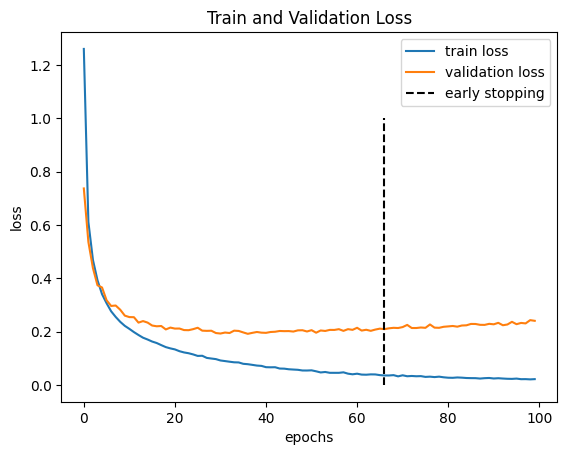

In [25]:
plt.plot(loss, label = 'train loss')
plt.plot(val_loss, label = 'validation loss')
plt.vlines(x = b_epoch, ymin = 0, ymax = 1,
           colors = 'k', linestyles = 'dashed',
           label = 'early stopping')

plt.legend()
plt.title('Train and Validation Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

Сделаем прогноз на обучающей выборке, а также на тестовых данных с использованием параметров после ранней остановки и параметров, достигнутых в конце обучения.

In [26]:
y_pred = predict(X_train, y_train_enc, params)
accuracy_score(y_train, y_pred)

0.9942708333333333

In [27]:
y_pred = predict(X_test, y_test_enc, b_params)
accuracy_score(y_test, y_pred)

0.9459

In [28]:
y_pred = predict(X_test, y_test_enc, params)
accuracy_score(y_test, y_pred)

0.9473

Теперь посмотрим, как эти и некоторые другие алгоритмы и инструменты можно реализовать в библиотеке Keras.

## Практика с Keras

### Подготовка данных
Вновь подгрузим данные.

In [29]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

### Создание модели

Объявим функцию, которая будет создавать объект класса Sequential с предобработкой данных, заданной архитектурой слоев и инициализированными параметрами. Кроме этого, сразу пропишем начальный размер шага и расписание его уменьшения.

Одновременно укажем тип оптимизатора, целевую функцию и метрику качества.

In [30]:
def create_model():

  # создадим объект класса Sequential
  model = keras.models.Sequential([
      # размерность одного наблюдения
      keras.Input(shape = (28, 28)),
      # слой для "вытягивания" картинок
      keras.layers.Flatten(),
      # приведение к диапазону от -1 до 1
      keras.layers.Rescaling(scale = 1./127.5, offset = -1),
      # полносвязные слои с соответствующим функциями активации
      keras.layers.Dense(64, activation = 'sigmoid'),
      keras.layers.Dense(64, activation = 'sigmoid'),
      keras.layers.Dense(10, activation = 'softmax')
      ])

  # объявим параметры Inverse Time Decay расписания
  initial_learning_rate = 0.001
  decay_rate, decay_steps = 0.01, 1.0

  # создадим объект класса InverseTimeDecay
  lr_schedule = keras.optimizers.schedules.InverseTimeDecay(
      initial_learning_rate,
      decay_steps, decay_rate)

  # соберем модель, прописав оптимизатор, целевую функцию и метрику качества
  model.compile(optimizer = keras.optimizers.Adam(learning_rate = lr_schedule),
                loss = 'categorical_crossentropy',
                metrics = ['accuracy'])

  return model

Создадим пока еще не обученную модель.

In [31]:
model = create_model()

### Сведения о модели
Посмотрим на тип созданного объекта.

In [32]:
type(model)

keras.src.models.sequential.Sequential

Выведем информацию о слоях и параметрах модели.

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

Кроме этого, создадим схему модели с помощью функции plot_model().

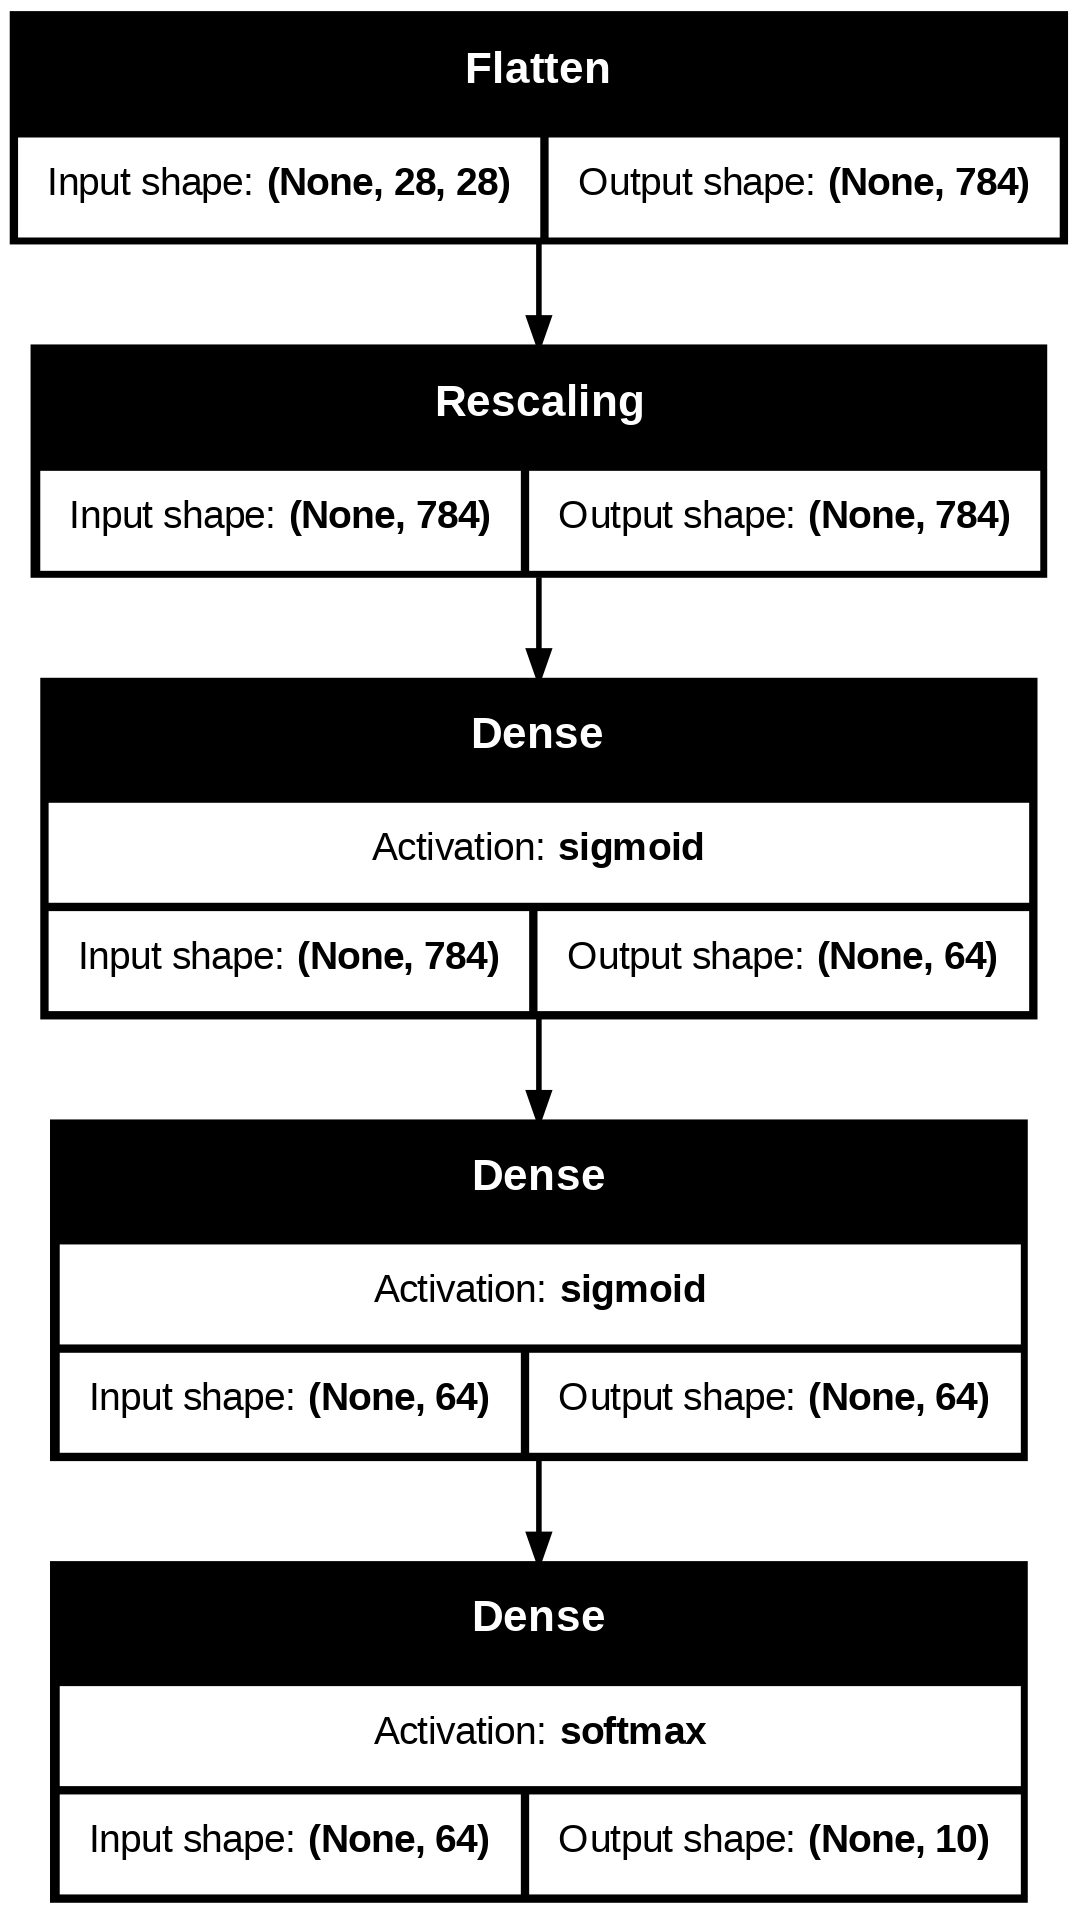

In [34]:
keras.utils.plot_model(model,
                       to_file = 'mnist_model.png',
                       show_shapes = True,
                       show_layer_activations = True)

Схема модели сохранится в сессионном хранилище.

### Callbacks
Для того чтобы применить раннюю остановку обучения, необходимо использовать callback.

Callback — это функция, которая вызывается в определенный момент в процессе обучения алгоритма.

#### EarlyStopping
Создадим объект класса EarlyStopping.

In [35]:
es_callback = keras.callbacks.EarlyStopping(monitor = 'val_accuracy',
                                            min_delta = 0,
                                            patience = 5,
                                            verbose = 2,
                                            restore_best_weights = True)

В частности, мы указали, что хотим отслеживать accuracy на валидационных данных с ожиданием без улучшения этой метрики в течение пяти эпох.

После этого мы останавливаем обучение и используем те параметры, которые показали наибольшее качество на валидационных данных.

#### ModelCheckpoint
Кроме этого, создадим еще один callback для сохранения весов модели. Сохраненные на диске (в сессионном хранилище) параметры можно будет загрузить в другую необученную модель с аналогичной архитектурой.

In [36]:
# сохраним параметры в файл best с расширением weights.h5
checkpoint_path = 'best.weights.h5'

cp_callback = keras.callbacks.ModelCheckpoint(filepath = checkpoint_path,
                                              save_best_only = True,
                                              save_weights_only = True,
                                              verbose = 0)

Созданные callbacks мы передадим в виде списка в метод .fit() на этапе обучения модели.

### Обучение модели
Обучим модель.

In [37]:
model.fit(X_train, keras.utils.to_categorical(y_train),
          epochs = 20,
          # keras самостоятельно выделит валидационное множество
          validation_split = 0.2,
          callbacks = [es_callback, cp_callback],
          verbose = 2)

Epoch 1/20
1500/1500 - 8s - 5ms/step - accuracy: 0.7962 - loss: 1.0575 - val_accuracy: 0.8744 - val_loss: 0.7099
Epoch 2/20
1500/1500 - 5s - 3ms/step - accuracy: 0.8707 - loss: 0.6548 - val_accuracy: 0.8868 - val_loss: 0.5742
Epoch 3/20
1500/1500 - 6s - 4ms/step - accuracy: 0.8827 - loss: 0.5648 - val_accuracy: 0.8918 - val_loss: 0.5150
Epoch 4/20
1500/1500 - 9s - 6ms/step - accuracy: 0.8875 - loss: 0.5186 - val_accuracy: 0.8960 - val_loss: 0.4808
Epoch 5/20
1500/1500 - 6s - 4ms/step - accuracy: 0.8906 - loss: 0.4895 - val_accuracy: 0.8985 - val_loss: 0.4573
Epoch 6/20
1500/1500 - 5s - 3ms/step - accuracy: 0.8929 - loss: 0.4691 - val_accuracy: 0.8997 - val_loss: 0.4407
Epoch 7/20
1500/1500 - 6s - 4ms/step - accuracy: 0.8943 - loss: 0.4539 - val_accuracy: 0.9025 - val_loss: 0.4276
Epoch 8/20
1500/1500 - 5s - 3ms/step - accuracy: 0.8965 - loss: 0.4419 - val_accuracy: 0.9032 - val_loss: 0.4170
Epoch 9/20
1500/1500 - 10s - 7ms/step - accuracy: 0.8976 - loss: 0.4321 - val_accuracy: 0.9043 -

Как мы видим, ранняя остановка не сработала (не было пяти эпох подряд с ухудшающейся валидационной accuracy), и модель запомнила веса эпохи 20.

Данные об изменениях уровня ошибки и accuracy содержатся в словаре.

In [38]:
model.history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

Посмотрим, как изменялась ошибка и accuracy.

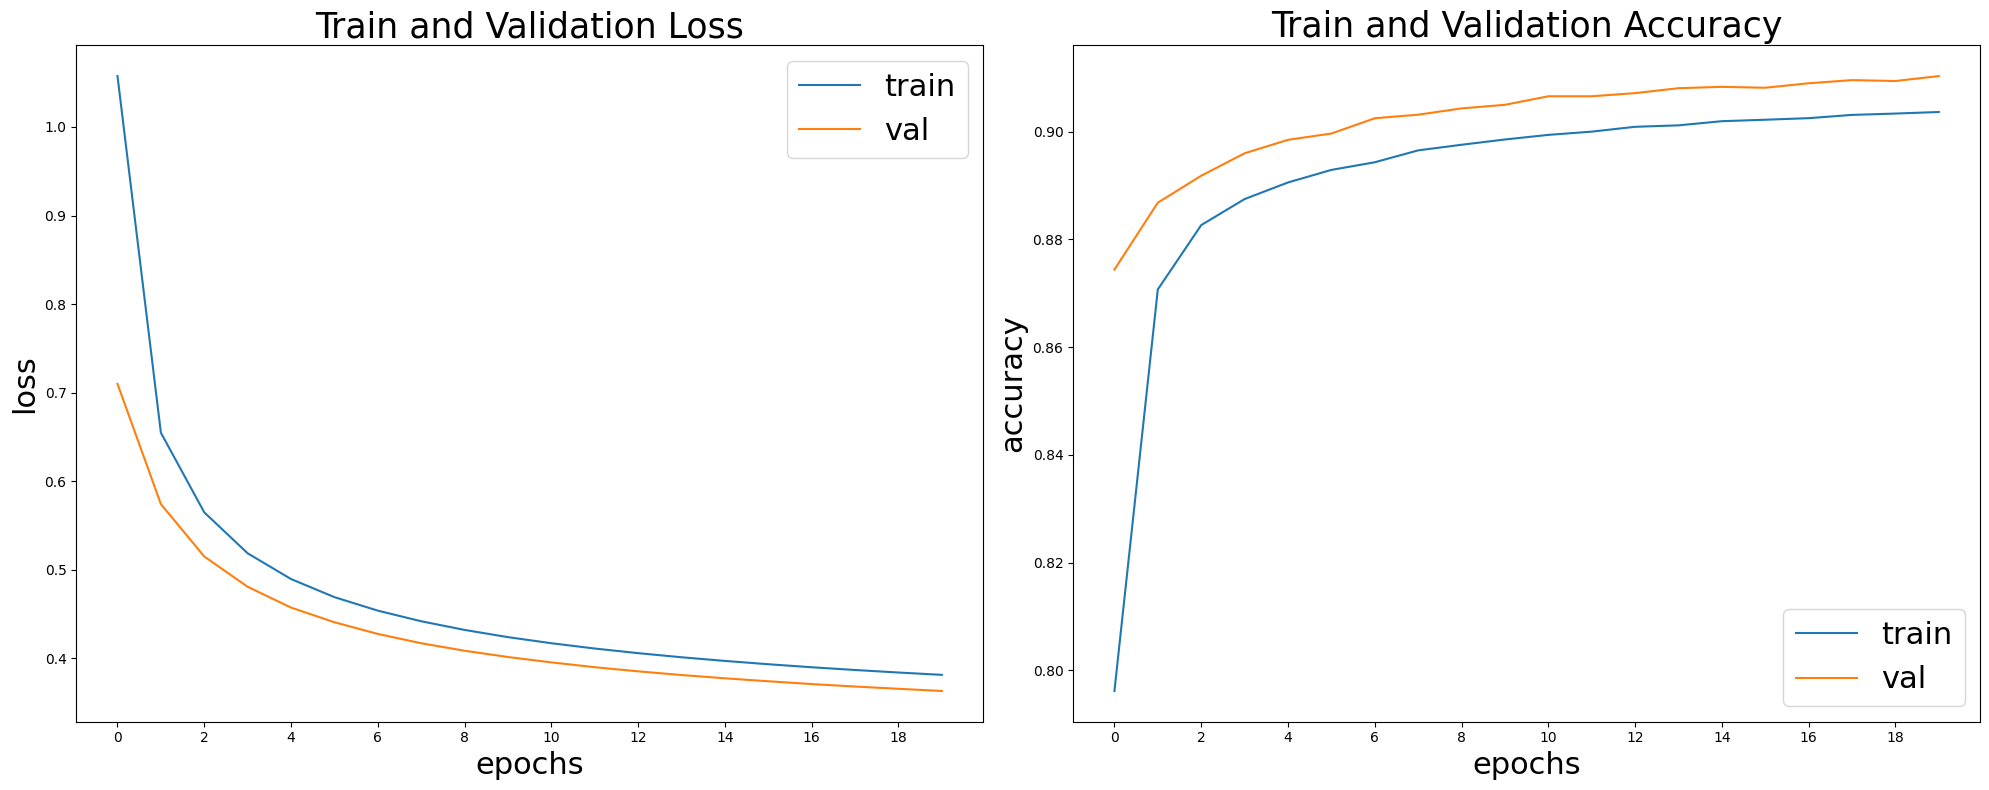

In [39]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2,
                               figsize = (20, 8))

ax1.plot(model.history.history['loss'])
ax1.plot(model.history.history['val_loss'])
ax1.set_title('Train and Validation Loss', fontsize = 25)
ax1.set_xlabel('epochs', fontsize = 22)
ax1.set_ylabel('loss', fontsize = 22)
ax1.set_xticks(np.arange(0, 20, step = 2))
ax1.legend(['train', 'val'], loc='upper right', fontsize = 22)

ax2.plot(model.history.history['accuracy'])
ax2.plot(model.history.history['val_accuracy'])
ax2.set_title('Train and Validation Accuracy', fontsize = 25)
ax2.set_xlabel('epochs', fontsize = 22)
ax2.set_ylabel('accuracy', fontsize = 22)
ax2.set_xticks(np.arange(0, 20, step = 2))
ax2.legend(['train', 'val'], loc='lower right', fontsize = 22)

plt.tight_layout()
plt.show()

### Оценка качества
Оценим уровень ошибки и accuracy на тестовых данных.

In [40]:
model.evaluate(X_test, keras.utils.to_categorical(y_test), verbose = 0)

[0.3654507100582123, 0.9086999893188477]

### Восстановление модели
Создадим необученную модель.

In [41]:
new_model = create_model()

Сделаем прогноз на инициализированных параметрах, чтобы убедиться, что модель не обучена.

In [42]:
new_model.evaluate(X_test, keras.utils.to_categorical(y_test), verbose = 0)

[2.4790008068084717, 0.0982000008225441]

Подгрузим сохраненные в сессионном хранилище параметры и снова сделаем прогноз.

In [ ]:
new_model.load_weights(checkpoint_path)
new_model.evaluate(X_test, keras.utils.to_categorical(y_test), verbose = 0)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 13 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[0.3663724362850189, 0.9090999960899353]